# 训练框架与优化器

> 假设训练语料只有一句「我爱机器学习」。模型看到 `<bos>` 后，起初可能只给「我」分配 10% 的概率。这个预测并不好，因此会得到一个较大的 loss。
>
> 接下来，反向传播会算出每个参数应该怎样调整，优化器再完成一次更新。如果更新方向有效，模型下一次给「我」的概率就会升高。语言模型的预训练，就是不断重复这样的过程。
>
> 本章从这一条六个 token 的句子开始。我们先构造输入与标签，手算一次 Cross-Entropy Loss，再让一个迷你模型真正完成前向传播、反向传播和参数更新。最后再把这些步骤对应到 Hugging Face Transformers 与 ModelScope SWIFT 的训练接口。

In [1]:
# 本章所有 import 集中放在第一个 code cell
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader

_ = torch.manual_seed(42)


## 1. 训练循环

一次训练从一条样本开始。模型先根据输入给出预测，再把预测与标签比较，得到一个表示预测误差的数值。这个数值称为 **loss**。

随后，`loss.backward()` 计算梯度，`optimizer.step()` 根据梯度调整参数。到这里，模型才真正完成了一次学习。把这个过程重复许多次，就得到 **训练循环（training loop）**。

我们先不展开训练库的工程功能。接下来从一条样本开始，每增加一个组件，就运行一次代码检查它的输入、输出和作用；到第 7 节再把这些组件组成完整训练循环。

## 2. 训练样本的构造

我们暂时不用真实 Tokenizer，而是为六个 token 直接指定编号。这样可以逐项检查输入与标签的对应关系。

```text
词表：
0=<pad>, 1=<bos>, 2=<eos>, 3=我, 4=爱, 5=机器, 6=学习

原句：我 爱 机器 学习
完整 token 序列：[<bos>, 我, 爱, 机器, 学习, <eos>]
数字形式：       [1,     3,  4, 5,   6,    2]
```

语言模型训练时，不是额外人工标注“答案”。答案就在原句的下一个 token 里：

```text
input_ids = [1, 3, 4, 5, 6]
labels    = [3, 4, 5, 6, 2]
```

也就是说：

```text
看到 <bos>             → 应该预测 我
看到 <bos> 我          → 应该预测 爱
看到 <bos> 我 爱       → 应该预测 机器
看到 <bos> 我 爱 机器  → 应该预测 学习
看到 <bos> 我 爱 机器 学习 → 应该预测 <eos>
```

这叫 **next-token prediction**：给前面的 token，预测下一个 token。


In [2]:
# 用具体数字构造 input_ids 和 labels
id_to_token = {
    0: "<pad>",
    1: "<bos>",
    2: "<eos>",
    3: "我",
    4: "爱",
    5: "机器",
    6: "学习",
}

sentence = torch.tensor([1, 3, 4, 5, 6, 2])
input_ids = sentence[:-1]
labels = sentence[1:]

print("完整句子:", sentence.tolist())
print("input_ids:", input_ids.tolist())
print("labels:   ", labels.tolist())
print()

for pos in range(len(input_ids)):
    context = [id_to_token[i.item()] for i in input_ids[:pos + 1]]
    target = id_to_token[labels[pos].item()]
    print(f"位置 {pos}: 看到 {context} -> 预测 {target}")

print()
print("关键观察：labels 不是人工额外写的答案。")
print("它来自同一句话的整体偏移。")


完整句子: [1, 3, 4, 5, 6, 2]
input_ids: [1, 3, 4, 5, 6]
labels:    [3, 4, 5, 6, 2]

位置 0: 看到 ['<bos>'] -> 预测 我
位置 1: 看到 ['<bos>', '我'] -> 预测 爱
位置 2: 看到 ['<bos>', '我', '爱'] -> 预测 机器
位置 3: 看到 ['<bos>', '我', '爱', '机器'] -> 预测 学习
位置 4: 看到 ['<bos>', '我', '爱', '机器', '学习'] -> 预测 <eos>

关键观察：labels 不是人工额外写的答案。
它来自同一句话的整体偏移。


## 3. Chat Template 与 Loss Mask

连续文本预训练时，每个非 padding token 都可以作为预测目标。对话微调则需要先区分提问与回答。先看一条只有一轮的对话：

```text
user: 2 + 2 等于几？
assistant: 4
```

`user` 部分提供上下文，`assistant` 部分提供要学习的回答。因此，我们保留整段对话作为输入，只让回答部分参与 loss：

```text
input_ids: [<user>, 2, +, 2, ?, <assistant>, 4, <eos>]
labels:    [-100,  -100, -100, -100, -100, -100, 4, <eos>]
```

PyTorch 的 `cross_entropy` 默认把标签 `-100` 视为忽略位置。这些位置仍在输入中，但不会进入 loss 的平均值。

把结构化对话转换成连续 token 序列的规则称为 **Chat Template**。通俗地说，它会给 `user` 和 `assistant` 的内容加上角色标记与边界标记，让模型知道每段文字由谁说出。

因此，一条 SFT 样本通常依次经过下面三步：

```text
messages -> apply_chat_template -> tokenize -> labels mask
```


In [3]:
# 手动模拟一次 Chat Template 和 label mask
vocab = {
    "<pad>": 0,
    "<user>": 1,
    "<assistant>": 2,
    "<eos>": 3,
    "2": 4,
    "+": 5,
    "=": 6,
    "?": 7,
    "4": 8,
}

chat_tokens = ["<user>", "2", "+", "2", "?", "<assistant>", "4", "<eos>"]
input_ids = torch.tensor([vocab[token] for token in chat_tokens])

# 只训练 assistant 回复：位置 6 和 7 参与 loss，其余位置忽略
labels = torch.tensor([-100, -100, -100, -100, -100, -100, vocab["4"], vocab["<eos>"]])

print("tokens:   ", chat_tokens)
print("input_ids:", input_ids.tolist())
print("labels:   ", labels.tolist())
print()

for token, label in zip(chat_tokens, labels.tolist()):
    if label == -100:
        print(f"{token:>11s} -> 不算 loss")
    else:
        print(f"{token:>11s} -> 算 loss，目标 token id = {label}")

print()
print("关键观察：user 部分提供上下文，不参与 loss。")
print("assistant 回复部分提供主要的训练目标。")


tokens:    ['<user>', '2', '+', '2', '?', '<assistant>', '4', '<eos>']
input_ids: [1, 4, 5, 4, 7, 2, 8, 3]
labels:    [-100, -100, -100, -100, -100, -100, 8, 3]

     <user> -> 不算 loss
          2 -> 不算 loss
          + -> 不算 loss
          2 -> 不算 loss
          ? -> 不算 loss
<assistant> -> 不算 loss
          4 -> 算 loss，目标 token id = 8
      <eos> -> 算 loss，目标 token id = 3

关键观察：user 部分提供上下文，不参与 loss。
assistant 回复部分提供主要的训练目标。


## 4. Cross-Entropy Loss

假设词表里只有 4 个 token，模型在某个位置给出下面四个数：

```text
[2.0, 1.0, 0.1, -1.0]
```

这四个数称为 **logits**，也就是模型给词表中每个 token 的原始分数。logits 还不是概率，需要先经过 softmax：

$$p_i = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

然后只看正确 token 的概率 $p_{correct}$：

$$loss = -\log(p_{correct})$$

负对数会把「正确 token 的概率较低」转换成「loss 较大」。代入三个概率即可看到这种对应关系：

```text
正确概率 = 1.0  -> -log(1.0)  = 0      很好
正确概率 = 0.5  -> -log(0.5)  = 0.693
正确概率 = 0.01 -> -log(0.01) = 4.605
```


In [4]:
# 手算一个位置的 Cross-Entropy Loss
logits = torch.tensor([2.0, 1.0, 0.1, -1.0])
correct_id = 0

exp_values = torch.exp(logits)
probs = exp_values / exp_values.sum()
correct_prob = probs[correct_id].item()
manual_loss = -math.log(correct_prob)

torch_loss = F.cross_entropy(logits.view(1, -1), torch.tensor([correct_id]))

print("logits:", logits.tolist())
print("exp(logits):", [round(x, 4) for x in exp_values.tolist()])
print("softmax 概率:", [round(x, 4) for x in probs.tolist()])
print()
print(f"正确 token id = {correct_id}")
print(f"正确 token 概率 = {correct_prob:.4f}")
print(f"手算 loss = -log({correct_prob:.4f}) = {manual_loss:.4f}")
print(f"PyTorch loss = {torch_loss.item():.4f}")
print()
print("关键观察：cross_entropy = log_softmax + 取正确类 + 负号。")


logits: [2.0, 1.0, 0.10000000149011612, -1.0]
exp(logits): [7.3891, 2.7183, 1.1052, 0.3679]
softmax 概率: [0.6381, 0.2347, 0.0954, 0.0318]

正确 token id = 0
正确 token 概率 = 0.6381
手算 loss = -log(0.6381) = 0.4493
PyTorch loss = 0.4493

关键观察：cross_entropy = log_softmax + 取正确类 + 负号。


## 5. Batch 与 Padding

一次只处理一条样本很难充分利用并行计算，因此训练时通常会同时处理多条样本。这样的一组样本称为 **batch**。

下面两条序列的长度分别是 6 和 5，暂时还不能放入同一个矩形张量：

```text
样本 A: [<bos>, 我, 爱, 机器, 学习, <eos>]     长度 6
样本 B: [<bos>, 我, 爱, 学习, <eos>]           长度 5
```

我们在较短序列末尾补上 `<pad>`，使两行长度相同。这个操作称为 padding：

```text
input_ids:
A: [1, 3, 4, 5, 6]
B: [1, 3, 4, 6, 0]

labels:
A: [3, 4, 5, 6, 2]
B: [3, 4, 6, 2, -100]
```

补齐之后还需要记录哪些位置来自原句。`attention_mask` 用 1 标记真实 token，用 0 标记 padding：

```text
A: [1, 1, 1, 1, 1]
B: [1, 1, 1, 1, 0]
```

负责执行 padding、生成 `attention_mask` 并整理 `labels` 的组件称为 **Data Collator**。下面实现一个最小版本。


In [5]:
# 实现一个极简 Data Collator，把不同长度的样本整理成 batch
def simple_collate(features, pad_id=0, ignore_index=-100):
    """
    把多条样本补齐成一个 batch。

    参数:
        features: 每条样本包含 input_ids 和 labels
        pad_id: input_ids 使用的 padding token id
        ignore_index: labels 使用的忽略标记

    返回:
        一个 batch 字典，包含 input_ids、attention_mask、labels
    """
    max_len = max(len(item["input_ids"]) for item in features)

    batch_input_ids = []
    batch_attention_mask = []
    batch_labels = []

    for item in features:
        input_ids = item["input_ids"]
        labels = item["labels"]
        pad_len = max_len - len(input_ids)

        batch_input_ids.append(input_ids + [pad_id] * pad_len)
        batch_attention_mask.append([1] * len(input_ids) + [0] * pad_len)
        batch_labels.append(labels + [ignore_index] * pad_len)

    return {
        "input_ids": torch.tensor(batch_input_ids),
        "attention_mask": torch.tensor(batch_attention_mask),
        "labels": torch.tensor(batch_labels),
    }

features = [
    {"input_ids": [1, 3, 4, 5, 6], "labels": [3, 4, 5, 6, 2]},
    {"input_ids": [1, 3, 4, 6], "labels": [3, 4, 6, 2]},
]

batch = simple_collate(features)

for name, value in batch.items():
    print(f"{name}: shape={tuple(value.shape)}")
    print(value)
    print()

print("关键观察：input_ids 用 pad_id 补齐，labels 用 -100 补齐。")
print("如果 labels 也用 pad_id，模型就会被迫学习预测 <pad>，这是错误的。")


input_ids: shape=(2, 5)
tensor([[1, 3, 4, 5, 6],
        [1, 3, 4, 6, 0]])

attention_mask: shape=(2, 5)
tensor([[1, 1, 1, 1, 1],
        [1, 1, 1, 1, 0]])

labels: shape=(2, 5)
tensor([[   3,    4,    5,    6,    2],
        [   3,    4,    6,    2, -100]])

关键观察：input_ids 用 pad_id 补齐，labels 用 -100 补齐。
如果 labels 也用 pad_id，模型就会被迫学习预测 <pad>，这是错误的。


## 6. 前向传播与损失计算

样本已经整理成 batch。下一步是把 `input_ids` 送入模型，得到预测分数与 loss。Transformers 常用下面的调用形式：

```python
outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
loss = outputs.loss
logits = outputs.logits
```

这里的 `labels` 不会作为模型输入。计算仍然按照下面的顺序进行：

```text
1. 模型用 input_ids 做 forward，得到 logits
2. 如果提供 labels，模型内部再计算 cross_entropy loss
3. 返回 outputs.loss 和 outputs.logits
```

因此，`labels` 只用于比较预测结果，不会把答案提前提供给模型。

下面实现一个极小的 Causal LM。它只包含 Embedding 和 Linear，目的是检查输入、logits 与 loss 的 shape；完整的 Transformer 结构在前面的章节已经实现。


In [6]:
class TinyCausalLM(nn.Module):
    """
    一个极小的 Causal Language Model，用来演示 Trainer 调用模型的接口。

    参数:
        vocab_size: 词表大小
        hidden_size: token 向量维度
    """
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.lm_head = nn.Linear(hidden_size, vocab_size)

    def forward(self, input_ids, attention_mask=None, labels=None):
        """
        输入 token ids，输出 logits；如果提供 labels，就同时计算 loss。

        参数:
            input_ids: [batch, seq_len]
            attention_mask: [batch, seq_len]，这里为了简化不参与计算
            labels: [batch, seq_len]，-100 的位置不算 loss

        返回:
            一个字典，包含 loss 和 logits
        """
        hidden = self.embedding(input_ids)
        logits = self.lm_head(hidden)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                labels.reshape(-1),
                ignore_index=-100,
            )

        return {"loss": loss, "logits": logits}

model = TinyCausalLM(vocab_size=9, hidden_size=16)
outputs = model(**batch)

print("logits shape:", tuple(outputs["logits"].shape))
print("loss:", round(outputs["loss"].item(), 4))
print()
print("关键观察：logits 是 [batch, seq_len, vocab_size]。")
print("loss 是把所有非 -100 的位置摊平后一起算平均。")


logits shape: (2, 5, 9)
loss: 1.8008

关键观察：logits 是 [batch, seq_len, vocab_size]。
loss 是把所有非 -100 的位置摊平后一起算平均。


## 7. 迷你 Trainer 的实现

现在，数据、labels、batch 和模型已经准备完成。把它们连起来，就得到一个最小训练 step：

```text
batch = next(dataloader)
outputs = model(**batch)
loss = outputs.loss
loss.backward()
optimizer.step()
optimizer.zero_grad()
```

完整训练还需要处理一些工程问题。它们不会改变 loss 与参数更新的数学含义，但会影响显存、速度和训练是否能够恢复：

| 工程功能 | 为什么需要 |
|:---|:---|
| gradient accumulation | 显存不够大 batch，就多次小 batch 累积梯度 |
| lr scheduler | 学习率不能永远固定，通常先 warmup 再下降 |
| mixed precision | 用 FP16/BF16 加速并省显存 |
| gradient clipping | 防止梯度突然爆炸 |
| checkpoint | 训练中断后能恢复 |
| eval / logging | 知道模型有没有真的变好 |
| distributed training | 多 GPU / 多机器并行训练 |

下面先实现不含分布式与混合精度的版本。运行后，我们将直接观察 loss 是否下降。


In [7]:
class ToyTextDataset(Dataset):
    """
    一个极小文本数据集，每条样本已经是 token ids。

    参数:
        sequences: 多条完整 token 序列，每条包含 BOS/EOS
    """
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        ids = self.sequences[index]
        return {
            "input_ids": ids[:-1],
            "labels": ids[1:],
        }

sequences = [
    [1, 3, 4, 5, 6, 2],
    [1, 3, 4, 6, 2],
    [1, 3, 4, 5, 2],
    [1, 3, 4, 6, 2],
]

dataset = ToyTextDataset(sequences)
dataloader = DataLoader(dataset, batch_size=2, shuffle=False, collate_fn=simple_collate)

model = TinyCausalLM(vocab_size=9, hidden_size=32)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.05)

print("训练前，先看一个 batch：")
first_batch = next(iter(dataloader))
for name, value in first_batch.items():
    print(name, tuple(value.shape))
print()
print("关键观察：Dataset 负责单条样本，DataLoader + collator 负责拼 batch。")


训练前，先看一个 batch：
input_ids (2, 5)
attention_mask (2, 5)
labels (2, 5)

关键观察：Dataset 负责单条样本，DataLoader + collator 负责拼 batch。


epoch 01 | train_loss = 2.0311
epoch 02 | train_loss = 0.6100
epoch 03 | train_loss = 0.3348
epoch 04 | train_loss = 0.2968
epoch 05 | train_loss = 0.2741
epoch 06 | train_loss = 0.2674
epoch 07 | train_loss = 0.2618
epoch 08 | train_loss = 0.2511

关键观察：每次 optimizer.step() 都会调整参数，loss 因而逐步下降。


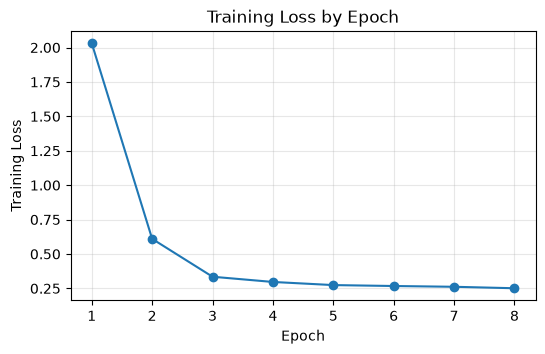

In [8]:
# 迷你训练 loop：这就是 Trainer 最核心的部分
num_epochs = 8
log_every = 1
loss_history = []

for epoch in range(num_epochs):
    total_loss = 0.0
    num_steps = 0

    for batch in dataloader:
        outputs = model(**batch)
        loss = outputs["loss"]

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        num_steps += 1

    avg_loss = total_loss / num_steps
    loss_history.append(avg_loss)
    if (epoch + 1) % log_every == 0:
        print(f"epoch {epoch + 1:02d} | train_loss = {avg_loss:.4f}")

print()
print("关键观察：每次 optimizer.step() 都会调整参数，loss 因而逐步下降。")

# 将同一组 loss 画出来，检查下降趋势是否稳定
plt.figure(figsize=(6, 3.5))
plt.plot(range(1, num_epochs + 1), loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss by Epoch")
plt.grid(alpha=0.3)
plt.show()


## 8. 优化器

前面的训练循环已经调用过 `optimizer.step()`。为了看清这一行的含义，先考虑一个参数：它当前等于 1.0，梯度为 0.5，学习率为 0.1。按照 SGD 的更新规则，新参数是 $1.0-0.1\times0.5=0.95$。

根据梯度计算参数改变量的算法称为 **优化器（optimizer）**。SGD 直接使用当前梯度；Adam 则记录过去若干步的梯度，使更新方向更平稳，并为不同参数调节更新幅度。

下面先用一个参数手算 Adam，再实现 `SimpleAdam` 与 PyTorch 的结果对照。AdamW、Gradient Clipping 和 Muon 都从这个基础继续展开。


### 8.1 Adam

Adam 不只看当前梯度，还为每个参数保存两组历史量。一阶矩 $m$ 是梯度的指数滑动平均，二阶矩 $v$ 是梯度平方的指数滑动平均。在第 $t$ 步得到梯度 $g_t$ 后：

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$

$m$ 用来平滑方向。如果连续几步的梯度同号，$m$ 会保留这个趋势；如果梯度正负交替，变化会相互抵消。

$v$ 用来调节幅度。某个参数长期得到较大的梯度时，它的 $v$ 也会较大，更新量会被分母 $\sqrt{v}+\epsilon$ 缩小。这就是 Adam 的自适应学习率。

两个状态都从 0 开始初始化，所以前几步的估计偏小。Adam 用 bias correction 修正：

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

当 $t$ 很大时 $\beta^t \to 0$，修正项趋于 1，只在初期显著放大估计值。最终更新公式：

$$\theta_t = \theta_{t-1} - \eta \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

典型超参：$\beta_1 = 0.9$、$\beta_2 = 0.999$、$\epsilon = 10^{-8}$。LLM 预训练里学习率通常在 $10^{-4}$ 量级。$\beta_2$ 设到 0.999 是因为梯度二阶矩变化比一阶矩慢，需要更长的滑动窗口才能稳定估计。


#### Adam 的单步更新

假设某个参数的初始值 $\theta_0 = 1.0$，第一步梯度 $g_1 = 0.5$，超参 $\beta_1 = 0.9$、$\beta_2 = 0.999$、$\eta = 0.1$、$\epsilon = 10^{-8}$。$m_0 = v_0 = 0$。

- $m_1 = 0.9 \cdot 0 + 0.1 \cdot 0.5 = 0.05$
- $v_1 = 0.999 \cdot 0 + 0.001 \cdot 0.25 = 0.00025$
- $\hat{m}_1 = 0.05 / (1 - 0.9) = 0.5$（等于 $g_1$，bias correction 把单步估计完全恢复）
- $\hat{v}_1 = 0.00025 / (1 - 0.999) = 0.25$（等于 $g_1^2$）
- $\Delta\theta = -0.1 \cdot 0.5 / (\sqrt{0.25} + 10^{-8}) = -0.1$
- $\theta_1 = 1.0 - 0.1 = 0.9$

这一步说明了 bias correction 的作用：虽然 $m$ 和 $v$ 从 0 开始，修正后的 $\hat{m}_1$ 与 $\hat{v}_1$ 仍能恢复第一步梯度及其平方。


In [9]:
torch.manual_seed(42)

# 手算验证：单个参数走一步 Adam
theta = torch.tensor([1.0], requires_grad=True)
theta.grad = torch.tensor([0.5])

optimizer = torch.optim.Adam([theta], lr=0.1, betas=(0.9, 0.999), eps=1e-8)
optimizer.step()

print(f"theta 更新前: 1.0")
print(f"theta 更新后: {theta.item():.6f}")
print(f"手算预期:     0.9")
print(f"误差:         {abs(theta.item() - 0.9):.2e}")
print()
print("关键观察：第一步 bias correction 让 Adam 更新幅度等于 lr * sign(grad)。")
print("如果不做 correction，更新幅度会被严重低估。")


theta 更新前: 1.0
theta 更新后: 0.900000
手算预期:     0.9
误差:         3.58e-08

关键观察：第一步 bias correction 让 Adam 更新幅度等于 lr * sign(grad)。
如果不做 correction，更新幅度会被严重低估。


#### SimpleAdam 的实现

下面把刚才的公式写进 `step()`。这个教学实现保留状态更新、bias correction 与参数更新，并省略 AMP、`foreach` 等工程优化。随后，我们会把它与 PyTorch 的 Adam 逐项比较。


In [10]:
class SimpleAdam(torch.optim.Optimizer):
    """简化版 Adam，只保留核心逻辑，方便对照公式阅读"""

    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        defaults = {"lr": lr, "betas": betas, "eps": eps}
        super().__init__(params, defaults)

    def step(self):
        for group in self.param_groups:
            lr = group["lr"]
            beta1, beta2 = group["betas"]
            eps = group["eps"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                grad = p.grad.data
                state = self.state[p]

                # 初次访问时初始化状态
                if "t" not in state:
                    state["t"] = 0
                    state["m"] = torch.zeros_like(p.data)
                    state["v"] = torch.zeros_like(p.data)

                state["t"] += 1
                t = state["t"]
                m, v = state["m"], state["v"]

                # 一阶矩和二阶矩的指数滑动平均
                m.mul_(beta1).add_(grad, alpha=1 - beta1)
                v.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)

                # bias correction
                m_hat = m / (1 - beta1 ** t)
                v_hat = v / (1 - beta2 ** t)

                # 参数更新
                p.data.sub_(lr * m_hat / (v_hat.sqrt() + eps))


# 验证：和 PyTorch 官方 Adam 在同样输入下输出一致
torch.manual_seed(0)
p1 = torch.randn(100, requires_grad=True)
p2 = p1.clone().detach().requires_grad_(True)
grad = torch.randn(100) * 0.1
p1.grad = grad.clone()
p2.grad = grad.clone()

opt_torch = torch.optim.Adam([p1], lr=1e-3)
opt_ours = SimpleAdam([p2], lr=1e-3)
opt_torch.step()
opt_ours.step()

max_diff = (p1 - p2).abs().max().item()
print(f"PyTorch Adam vs SimpleAdam 第一步最大差异: {max_diff:.2e}")

# 再走 99 步
for _ in range(99):
    g = torch.randn(100) * 0.1
    p1.grad = g.clone()
    p2.grad = g.clone()
    opt_torch.step()
    opt_ours.step()

max_diff = (p1 - p2).abs().max().item()
print(f"100 步后最大差异: {max_diff:.2e}")
print("关键观察：教学实现和 PyTorch Adam 的数值一致。")


PyTorch Adam vs SimpleAdam 第一步最大差异: 1.16e-10
100 步后最大差异: 5.96e-08
关键观察：教学实现和 PyTorch Adam 的数值一致。


### 8.2 AdamW 与 Weight Decay

Adam 原始论文里如果要加 weight decay（L2 正则），做法是把 $\lambda \theta$ 加到梯度上：$g_t^{\text{reg}} = g_t + \lambda \theta$，然后让这个修改后的梯度进入 $m$、$v$ 的更新。

这样处理时，$\lambda \theta$ 也会经过 $m/\sqrt{v}$ 的自适应缩放。于是，同一个 weight decay 系数会在不同参数上产生不同强度，不再等同于按固定比例缩小参数。

AdamW（Loshchilov & Hutter, 2019）的做法是把 weight decay 从梯度链路里解耦出来：直接在参数上做衰减，不经过 $m / \sqrt{v}$。更新公式变成：

$$\theta_t = \theta_{t-1} - \eta \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} - \eta \lambda \theta_{t-1}$$

工程上通常把 decay 项放在 Adam update 之前（`p.data -= lr * weight_decay * p.data`），这样后面的 $\hat{m}/\sqrt{\hat{v}}$ 是基于衰减后的参数算的。


#### 参数分组

常见训练配置会让 Linear 与 Embedding 的二维权重参与 weight decay，并把 bias、LayerNorm 或 RMSNorm 的一维参数放入不衰减组。具体选择属于训练配置，而不是 AdamW 强制规定。

PyTorch 里用 parameter group 区分：`p.dim() >= 2` 是一个常用的启发式——2D 及以上的 tensor 通常是 Linear/Conv/Embedding 的权重，1D 的通常是 bias 和 LayerNorm 的 $\gamma, \beta$。


In [11]:
# 一个极简的 decoder-only 模型骨架，用来演示参数分组
class TinyBlock(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.ln = nn.LayerNorm(d)
        self.fc = nn.Linear(d, d * 4)
        self.proj = nn.Linear(d * 4, d)

    def forward(self, x):
        return self.proj(torch.nn.functional.gelu(self.fc(self.ln(x))))


model = nn.Sequential(
    nn.Embedding(1000, 64),
    TinyBlock(64),
    TinyBlock(64),
    nn.Linear(64, 1000),
)

# 按维度分组：2D 及以上 decay，1D 不 decay
decay, no_decay = [], []
for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if p.dim() >= 2:
        decay.append(p)
    else:
        no_decay.append(p)

print(f"decay 参数数量:    {len(decay)}, 总元素: {sum(p.numel() for p in decay)}")
print(f"no_decay 参数数量: {len(no_decay)}, 总元素: {sum(p.numel() for p in no_decay)}")
print()
print("典型分布：decay 组主要包含 Linear/Embedding 权重。")
print("no_decay 组主要包含 bias 和 LayerNorm 参数。")


decay 参数数量:    6, 总元素: 193536
no_decay 参数数量: 9, 总元素: 1896

典型分布：decay 组主要包含 Linear/Embedding 权重。
no_decay 组主要包含 bias 和 LayerNorm 参数。


### 8.3 Gradient Clipping

假设一组参数梯度的 global norm 通常在 0.8 左右，某一步却上升到 180。若直接更新，这一步的参数改变量也会异常增大。**Gradient Clipping** 为梯度范数设置上限，用来限制单次更新幅度。

LLM 里最常用的是 global norm clip：先计算所有参数梯度的 global L2 norm $\|g\| = \sqrt{\sum_i \|g_i\|^2}$，如果超过阈值 $\tau$，就把所有梯度按 $\tau / \|g\|$ 等比缩小：

$$g \leftarrow g \cdot \min\left(1, \frac{\tau}{\|g\|}\right)$$

这种做法保留了各参数梯度的相对方向，只整体缩放幅度。阈值 $\tau$ 在 GPT-3、LLaMA 等大模型里通常设为 1.0。

下面构造一组 global norm 约为 180 的梯度，并把阈值设为 1.0。代码会同时显示裁剪前后的范数，以验证缩放结果。


In [12]:
def clip_grad_norm_(params, max_norm, eps=1e-6):
    """从零实现 global norm clip，等价于 torch.nn.utils.clip_grad_norm_

    参数:
        params: 可迭代的参数（grad 不能为 None）
        max_norm: 梯度 global norm 的上限
        eps: 防 0 的小常数
    """
    grads = [p.grad for p in params if p.grad is not None]
    if len(grads) == 0:
        return torch.tensor(0.0)

    # 计算 global norm：所有梯度 L2 norm 平方之和再开方
    total_norm_sq = sum(g.float().pow(2).sum() for g in grads)
    total_norm = total_norm_sq.sqrt()

    # 如果超过阈值，等比缩小所有梯度
    clip_coef = max_norm / (total_norm + eps)
    if clip_coef < 1:
        for g in grads:
            g.mul_(clip_coef)

    return total_norm


# 验证：构造一组梯度，global norm 远超 1.0
params = [torch.randn(100, requires_grad=True) for _ in range(3)]
for p in params:
    p.grad = torch.randn(100) * 10  # 故意放大梯度

before_norm = torch.sqrt(sum(p.grad.float().pow(2).sum() for p in params)).item()
print(f"clip 前的 global norm: {before_norm:.2f}")

returned = clip_grad_norm_(params, max_norm=1.0)
after_norm = torch.sqrt(sum(p.grad.float().pow(2).sum() for p in params)).item()
print(f"clip 后的 global norm: {after_norm:.4f}")
print()
print("关键观察：clip 后 global norm 被压到 1.0 附近，但梯度方向被保留。")
print("clip 不会放大梯度——原始 norm 小于阈值时，clip_coef >= 1 但不应用。")


clip 前的 global norm: 180.46
clip 后的 global norm: 1.0000

关键观察：clip 后 global norm 被压到 1.0 附近，但梯度方向被保留。
clip 不会放大梯度——原始 norm 小于阈值时，clip_coef >= 1 但不应用。


### 8.4 Muon

Linear 层的权重 $W \in \mathbb{R}^{m \times n}$ 是二维矩阵，它的梯度 $G$ 也具有相同形状。Adam 对每个元素分别缩放；Muon 则把 $G$ 作为一个整体矩阵处理。

正交化的直觉：把梯度 $G$ 做 SVD 分解 $G = U \Sigma V^\top$，正交化就是把奇异值全部替换成 1，得到 $U V^\top$。这样更新方向的幅度被归一化，只有方向被保留——类似于 sign-gradient，但保留了矩阵的所有方向信息。

SVD 可以直接得到这个结果，但计算代价较高。Muon 使用 Newton-Schulz 迭代近似完成正交化：

$$X_{k+1} = \frac{1}{2} X_k (3 I - X_k^\top X_k)$$

从 $X_0 = G / \|G\|_F$ 出发，重复若干次矩阵乘法，$X_k$ 会逐渐接近 $U V^\top$。下面用 $8\times16$ 的随机矩阵检查 $X X^\top$ 是否接近单位矩阵。

Muon 只对 2D 矩阵参数用。1D 参数（bias、LayerNorm）没有矩阵结构，正交化无意义，仍然用 Adam。所以实际使用时是「Muon for 2D + Adam for 1D」的混合优化器。


In [13]:
torch.manual_seed(42)


def newton_schulz(G, steps=7):
    """用 Newton-Schulz 迭代近似把 G 正交化

    参数:
        G: 2D 梯度矩阵
        steps: 迭代次数，7-10 次通常足够
    返回:
        近似正交化后的矩阵，形状与 G 相同
    """
    assert G.dim() == 2, "Newton-Schulz 只适用于 2D 矩阵"
    X = G.bfloat16() if G.is_cuda else G.float()
    # 归一化：让谱半径 < 1.5，保证迭代收敛
    X = X / (X.norm() + 1e-7)
    for _ in range(steps):
        A = X @ X.t()
        B = A @ X
        X = 1.5 * X - 0.5 * B
    return X


# 验证 Newton-Schulz 的正交化效果
G = torch.randn(8, 16)
X = newton_schulz(G, steps=7)

# 正交化的判据：X X^T 接近单位矩阵
gram = X @ X.t()
identity = torch.eye(8)
off_diag = (gram - identity).abs().max().item()
diag_dev = (gram.diag() - 1.0).abs().max().item()

print(f"输入矩阵 G 形状: {tuple(G.shape)}")
print(f"迭代 7 次后 X X^T 的对角线偏离 1: {diag_dev:.2e}")
print(f"迭代 7 次后 X X^T 的非对角线最大值:   {off_diag:.2e}")
print()
print("关键观察：Newton-Schulz 迭代 7 步后，X X^T 已非常接近单位矩阵。")
print("等价于把 G 的 SVD 奇异值全部替换为 1，保留了方向但归一化了幅度。")


输入矩阵 G 形状: (8, 16)
迭代 7 次后 X X^T 的对角线偏离 1: 3.27e-03
迭代 7 次后 X X^T 的非对角线最大值:   3.27e-03

关键观察：Newton-Schulz 迭代 7 步后，X X^T 已非常接近单位矩阵。
等价于把 G 的 SVD 奇异值全部替换为 1，保留了方向但归一化了幅度。


#### Muon 的简化实现

下面把 Newton-Schulz 迭代放入 `step()`，并加入 momentum。这个教学版本省略了原实现中的部分缩放与参数形状处理，只用来观察二维参数如何得到正交化后的更新方向。完整实现可参考 [KellerJordan/Muon](https://github.com/KellerJordan/Muon)。

Muon 与 Adam 的更新尺度不同，因此二者的学习率不能直接互换。示例使用 $4 \times 10^{-3}$，只用于检查一次更新是否按预期发生。


In [14]:
class SimpleMuon(torch.optim.Optimizer):
    """简化版 Muon：对 2D 参数用 Newton-Schulz 正交化，对 1D 退化为 momentum SGD

    参数:
        params: 待优化参数
        lr: 学习率（Muon 通常 4e-3，比 Adam 大一个数量级）
        momentum: 一阶矩衰减系数
        ns_steps: Newton-Schulz 迭代次数
    """

    def __init__(self, params, lr=4e-3, momentum=0.95, ns_steps=5):
        defaults = {"lr": lr, "momentum": momentum, "ns_steps": ns_steps}
        super().__init__(params, defaults)

    def step(self):
        for group in self.param_groups:
            lr = group["lr"]
            momentum = group["momentum"]
            ns_steps = group["ns_steps"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                grad = p.grad
                state = self.state[p]

                if len(state) == 0:
                    state["momentum_buffer"] = torch.zeros_like(p)

                buf = state["momentum_buffer"]
                buf.mul_(momentum).add_(grad)

                if p.dim() >= 2:
                    # 2D 参数：用 Newton-Schulz 正交化 momentum
                    update = newton_schulz(buf, steps=ns_steps)
                    # 按 sqrt(max(m, n)) 缩放，匹配原版 Muon 的幅度控制
                    scale = max(1.0, buf.shape[0] / buf.shape[1]) ** 0.5
                    p.data.add_(update, alpha=-lr * scale)
                else:
                    # 1D 参数：退化为普通 momentum SGD
                    p.data.add_(buf, alpha=-lr)


# 冒烟测试：Muon 能跑、参数会变
torch.manual_seed(0)
p = torch.randn(32, 64, requires_grad=True)
p.grad = torch.randn(32, 64) * 0.1
before = p.data.clone()
opt = SimpleMuon([p], lr=4e-3, ns_steps=7)
opt.step()
delta = (p - before).abs().mean().item()
print(f"参数平均更新幅度: {delta:.6f}")
print(f"参数维度: {tuple(p.shape)}")
print("关键观察：Muon 对 2D 参数应用 Newton-Schulz 正交化后的更新方向。")


参数平均更新幅度: 0.000390
参数维度: (32, 64)
关键观察：Muon 对 2D 参数应用 Newton-Schulz 正交化后的更新方向。


### 8.5 Lion、Shampoo 与 SOAP

前面的 Adam 按元素处理梯度，Muon 按矩阵处理二维梯度。沿着这两个方向，还可以理解 Lion、Shampoo 与 SOAP 的区别。

**Lion** 使用 momentum 的符号作为更新方向：$\theta \leftarrow \theta - \eta \cdot \text{sign}(m)$。它不保存 Adam 的二阶矩 $v$，因此每个参数少一份优化器状态，但需要重新选择学习率与 weight decay。

**Shampoo** 为梯度矩阵维护左右两个预处理矩阵 $L = \mathbb{E}[g g^\top]$ 与 $R = \mathbb{E}[g^\top g]$，并用 $L^{-1/4} G R^{-1/4}$ 计算更新方向。它利用了更多矩阵结构，同时增加了状态存储与矩阵运算。

**SOAP** 将矩阵预处理与 Adam 式逐元素更新结合起来，并降低部分矩阵状态的更新频率。它试图在利用矩阵结构与控制计算开销之间取得平衡。

这三个优化器和 Adam/Muon 的核心区别在于对梯度矩阵结构信息的利用程度：

| 优化器 | 梯度处理方式 | 主要附加状态 |
|:---|:---|:---|
| Adam/AdamW | 逐元素的一阶矩与二阶矩 | $m$、$v$ |
| Lion | 逐元素的 momentum 符号 | $m$ |
| Muon | 二维矩阵正交化 | momentum |
| Shampoo | 左右矩阵预处理 | $L$、$R$ |
| SOAP | 低频矩阵预处理与逐元素修正 | 矩阵状态与 Adam 状态 |

这些算法的更新尺度与状态开销不同。更换优化器时，需要重新比较学习率、weight decay、warmup、显存占用和验证集 loss，不能只替换类名。


### 8.6 优化器比较

下面的数值只是常见起点，不是可以直接复用的固定答案：

| 训练阶段 | 推荐优化器 | 典型学习率 | 备注 |
|:---|:---|:---|:---|
| 预训练（dense） | AdamW | $3 \times 10^{-4}$ | 社区调参最充分，首选 |
| 预训练（MoE） | AdamW | $3 \times 10^{-4}$ | router 单独设更小 lr |
| SFT / 指令微调 | AdamW | $10^{-5}$ 到 $10^{-4}$ | weight decay 通常设为 0 |
| RLHF（PPO） | AdamW | actor 更小 | actor/critic 不同 lr |
| 中等规模实验 | Muon | $4 \times 10^{-3}$ | 2D 用 Muon，1D 用 Adam |

切换优化器必须重新调学习率——Adam 的 lr 不能直接用到 Muon 上，反过来也一样。


## 9. Hugging Face Transformers 训练接口

我们已经实现了 Dataset、Data Collator、模型和训练循环。把同样的任务交给 Transformers 时，可以写成下面的形式：

```python
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import DataCollatorForLanguageModeling
from transformers import Trainer, TrainingArguments

model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-0.5B")
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B")

collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,  # Causal LM，不是 BERT 那种 masked LM
)

args = TrainingArguments(
    output_dir="outputs/qwen-sft",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=2e-5,
    num_train_epochs=3,
    logging_steps=10,
    save_steps=500,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    data_collator=collator,
)

trainer.train()
```

逐行对照可以看到，`trainer.train()` 只是把已经实现过的组件组织起来：

| 本章实现的组件 | Transformers 里的组件 |
|:---|:---|
| `ToyTextDataset` | `Dataset` / `datasets.Dataset` |
| `simple_collate` | `DataCollatorForLanguageModeling` 或自定义 collator |
| `TinyCausalLM` | `AutoModelForCausalLM` |
| `optimizer` | Trainer 内部创建的 AdamW 或自定义 optimizer |
| `for epoch... for batch...` | `trainer.train()` |
| `outputs = model(**batch)` | Trainer 内部的 `training_step` |
| `loss.backward()` | Trainer / Accelerate 处理 backward |
| `optimizer.step()` | Trainer 内部按梯度累积节奏 step |

注意一个细节：纯文本继续预训练（CPT）和对话 SFT 的 collator 不完全一样。

| 训练类型 | labels 通常怎么算 |
|:---|:---|
| 继续预训练 / Causal LM | 基本所有非 PAD token 都算 loss |
| 指令微调 / SFT | user/system 部分多半设为 `-100`，主要训练 assistant 回复 |


## 10. ModelScope SWIFT 训练接口

同一类 SFT 任务也可以通过下面的命令配置：

```bash
swift sft \
  --model Qwen/Qwen2.5-0.5B-Instruct \
  --dataset your_dataset.jsonl \
  --train_type lora \
  --learning_rate 2e-5 \
  --per_device_train_batch_size 2 \
  --gradient_accumulation_steps 8 \
  --num_train_epochs 3 \
  --output_dir output/qwen-lora
```

提供这组训练入口的工具称为 **ModelScope SWIFT**，包名为 `ms-swift`。它把模型加载、Chat Template、LoRA、分布式配置与评测等步骤组织成命令行参数。

这些参数仍然可以逐项对应到本章实现的训练循环：

| `ms-swift` 参数/功能 | 背后的训练环节 |
|:---|:---|
| `--model` | 加载模型和 tokenizer |
| `--dataset` | 读取原始样本，转成训练 dataset |
| 模型 template | 把 messages 转成模型需要的 Chat Template |
| `--train_type lora` | 只给部分低秩参数打开梯度 |
| `--per_device_train_batch_size` | 每张卡一次处理多少条样本 |
| `--gradient_accumulation_steps` | 几个小 batch 合成一次大更新 |
| `--learning_rate` | optimizer 的步长 |
| `--deepspeed` / 分布式参数 | 多卡切分模型状态、梯度、优化器状态 |
| `--output_dir` | 保存 checkpoint 和日志 |

因此，`ms-swift` 改变的是训练的组织方式，不是 loss、backward 与参数更新的数学过程：

```text
batch -> model forward -> loss -> backward -> optimizer step
```


## 11. 训练流程总结

现在再回到完整流程。开头的六个 token 已经依次经过下面这些步骤，每一步都能与前面的代码对应：

```text
1. 原始数据
   纯文本："我爱机器学习"
   对话：[{role: user, content: ...}, {role: assistant, content: ...}]

2. 模板化
   apply_chat_template(messages)
   -> "<user>...<assistant>..."

3. Tokenize
   tokenizer(text)
   -> input_ids

4. 构造 labels
   继续预训练：labels ≈ input_ids 的下一个 token
   SFT：user/system 位置设为 -100，assistant 位置保留答案

5. Data Collator
   多条样本 pad 到同一长度
   -> input_ids / attention_mask / labels

6. Forward
   outputs = model(**batch)
   -> logits: [batch, seq_len, vocab_size]
   -> loss: 有效 token 的平均 cross-entropy

7. Backward
   loss.backward()
   -> 每个可训练参数得到梯度

8. Optimizer Step
   AdamW / 8-bit Adam / 其他 optimizer
   -> 更新参数

9. Scheduler / Logging / Eval / Checkpoint
   学习率调整、记录 loss、跑验证集、保存权重
```

使用 LoRA 时，训练循环保持不变，只是可训练参数变成 LoRA 的 A、B 矩阵：

```text
原模型大部分参数 frozen，只训练 LoRA 的 A/B 小矩阵。
```

使用 DeepSpeed ZeRO 或 FSDP 时，参数与优化器状态会分布到多张 GPU，loss、backward 和 step 的关系仍然不变：

```text
参数、梯度、优化器状态被切到多张 GPU 上，但数学上的 loss/backward/step 不变。
```


## 12. 损失函数的信息论解释

假设某次验证的平均 Cross-Entropy 为 2.0。计算 $\exp(2.0)$，得到 7.39。这个数称为 **Perplexity（PPL）**，可以帮助我们把对数尺度的 loss 换成更容易比较的尺度。

从这个换算出发，我们再说明 Cross-Entropy、Entropy 与 KL Divergence 之间的关系。


### 12.1 Perplexity

Cross-Entropy loss 是一个对数刻度的数字，单看数值不容易建立直觉。Perplexity（PPL）是 CE 的指数化版本：

$$ \text{PPL} = \exp(\text{CE}) $$

PPL 可以用下面的近似直觉理解：模型在每个位置上，等价于在多少个 token 之间均匀地犹豫。

几个具体数字建立直觉：

| CE loss | PPL | 含义 |
|:---|:---|:---|
| 0 | 1.0 | 模型完全确定正确 token，没有犹豫 |
| 2.0 | 7.39 | 模型在每个位置平均在 7-8 个 token 之间犹豫 |
| 4.6 | 100 | 犹豫范围扩大到约 100 个 token |
| $\log V$ | $V$ | 模型对词表中的 token 给出均匀分布 |

其中 $V$ 是词表大小。模型给出均匀分布时，PPL 恰好等于 $V$；这不是 PPL 的上界，因为模型也可能给正确 token 分配低于均匀分布的概率。

比较 PPL 时需要保持数据集与 Tokenizer 一致。语料难度或 token 切分方式发生变化，PPL 的绝对值也会变化。


    CE |          PPL | 直觉
--------------------------------------------------
  0.00 |         1.00 | 完全确定，没有犹豫
  1.00 |         2.72 | 平均在约 2.7 个 token 之间犹豫
  2.00 |         7.39 | 平均在约 7.4 个 token 之间犹豫
  3.00 |        20.09 | 平均在约 20.1 个 token 之间犹豫
  4.60 |        99.48 | 平均在约 99.5 个 token 之间犹豫
 10.82 |     50000.00 | 等于在 50000 词表上给出均匀分布

关键观察：PPL 把对数尺度的 loss 翻译成线性尺度，更接近直觉。
比较 PPL 时，必须使用同一份语料和同一个 Tokenizer。


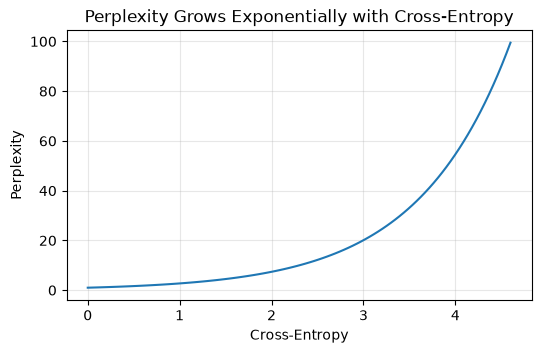

In [15]:
# 用具体数字看 CE 和 PPL 之间的换算
ce_values = [0.0, 1.0, 2.0, 3.0, 4.6, math.log(50000)]

print(f"{'CE':>6} | {'PPL':>12} | 直觉")
print("-" * 50)
for ce in ce_values:
    ppl = math.exp(ce)
    if ce == 0.0:
        note = "完全确定，没有犹豫"
    elif ce == math.log(50000):
        note = "等于在 50000 词表上给出均匀分布"
    else:
        note = f"平均在约 {ppl:.1f} 个 token 之间犹豫"
    print(f"{ce:>6.2f} | {ppl:>12.2f} | {note}")

print()
print("关键观察：PPL 把对数尺度的 loss 翻译成线性尺度，更接近直觉。")
print("比较 PPL 时，必须使用同一份语料和同一个 Tokenizer。")

# 绘制常用区间，观察 CE 与 PPL 的指数关系
curve_ce = torch.linspace(0, 4.6, 100)
curve_ppl = torch.exp(curve_ce)
plt.figure(figsize=(6, 3.5))
plt.plot(curve_ce, curve_ppl)
plt.xlabel("Cross-Entropy")
plt.ylabel("Perplexity")
plt.title("Perplexity Grows Exponentially with Cross-Entropy")
plt.grid(alpha=0.3)
plt.show()


### 12.2 Cross-Entropy、KL Divergence 与 Entropy

Cross-Entropy、KL divergence 和 entropy 三者共享一个恒等式：

$$ H(p, q) = H(p) + D_{KL}(p \| q) $$

其中 $p$ 是真实分布，$q$ 是模型预测分布。$H(p, q)$ 是 cross-entropy，$H(p)$ 是真实分布的 entropy，$D_{KL}(p \| q)$ 是 KL 散度，衡量两个分布的差异。

在 teacher forcing 的语言模型训练里，「真实分布」是 one-hot：正确 token 概率为 1，其他 token 概率为 0。one-hot 分布的 entropy 为 0：

$$ H(p) = -\sum_i p_i \log p_i = -1 \cdot \log 1 = 0 $$

所以 teacher forcing 下有：

$$ \text{CE}(p, q) = D_{KL}(p \| q) $$

这就是为什么训练语言模型时，CE loss 和 KL divergence 的数值完全一致。这并不是巧合，而是 one-hot 监督把 entropy 项归零后的结果。



In [16]:
# 用数值验证：teacher forcing 下 CE == KL
# 词表大小为 5，正确 token 是 id=2
p = torch.tensor([0.0, 0.0, 1.0, 0.0, 0.0])  # one-hot 真实分布
logits = torch.tensor([1.2, 0.5, 2.8, -0.3, 0.1])
q = F.softmax(logits, dim=-1)  # 模型预测分布

# Cross-Entropy: -sum p_i * log q_i
log_q = torch.log(q)
ce = -(p * log_q).sum().item()

# entropy of p: -sum p_i * log p_i
# p 里只有 id=2 是 1，log(1)=0，所以 H(p) = 0
entropy_p = -(p * torch.log(p.clamp_min(1e-12))).sum().item()

# KL(p || q) = -sum p_i * log(q_i / p_i)
kl = (p * (torch.log(p.clamp_min(1e-12)) - log_q)).sum().item()

print(f"H(p)      = {entropy_p:.4f}")
print(f"CE(p, q)  = {ce:.4f}")
print(f"KL(p||q)  = {kl:.4f}")
print()
print(f"验证 CE == H(p) + KL: {entropy_p:.4f} + {kl:.4f} = {entropy_p + kl:.4f}")
print("关键观察：teacher forcing 的真实分布是 one-hot，因此 H(p)=0。")
print("所以，此时 CE 和 KL 的数值相同。")


H(p)      = -0.0000
CE(p, q)  = 0.3467
KL(p||q)  = 0.3467

验证 CE == H(p) + KL: -0.0000 + 0.3467 = 0.3467
关键观察：teacher forcing 的真实分布是 one-hot，因此 H(p)=0。
所以，此时 CE 和 KL 的数值相同。


### 12.3 不同训练目标中的应用

当训练目标需要比较两个概率分布时，CE、KL 与 entropy 会以不同形式出现。下面只比较它们各自承担的作用：

| 训练范式 | 用的形式 | 为什么用这个 |
|:---|:---|:---|
| 预训练 / SFT | CE loss | 监督信号是 one-hot，CE = KL，简单直接 |
| 知识蒸馏 | KL divergence | teacher 是软标签分布，不再是 one-hot，要衡量两个完整分布的差异 |
| RLHF (PPO) | KL penalty | 在 reward 之外加一项 KL(policy \| reference)，防止策略跑偏 |
| DPO | log-ratio（隐含 KL） | 通过 log σ(β log(π/π_ref)) 的形式，等价于一种隐式 KL 约束 |
| MoE load balancing | entropy / KL 形式 | 鼓励 router 更均衡地分配 token |

以 MoE 为例，可以把 router 分给各 expert 的概率看成分布 $r$。load balancing loss 用 entropy 或与均匀分布的 KL 形式约束这个分布，减少长期集中到少数 expert 的情况。

在 teacher forcing 中，真实分布是 one-hot，因而 $H(p)=0$，Cross-Entropy 与 $D_{KL}(p\|q)$ 数值相同。知识蒸馏使用软标签后，$H(p)$ 不再为 0，此时就需要保留完整的分布关系。


## 13. 标签偏移

有些教程会写：

```python
input_ids = tokens[:-1]
labels = tokens[1:]
```

但很多 Transformers 模型训练时又会写：

```python
input_ids = tokens
labels = tokens
```

这不是矛盾。区别在于 **shift 发生在哪里**。

| 写法 | shift 发生位置 | 适合讲解什么 |
|:---|:---|:---|
| `input=tokens[:-1]`, `labels=tokens[1:]` | 数据处理阶段 | 最适合教学，关系最清楚 |
| `input=tokens`, `labels=tokens` | 模型内部算 loss 时 shift | 训练接口中常见，省掉外部切片 |

很多 `AutoModelForCausalLM` 在内部算 loss 时，会把 logits 和 labels 对齐成：

```text
shift_logits = logits[..., :-1, :]
shift_labels = labels[..., 1:]
```

因此，即使代码写成 `labels=input_ids`，模型内部比较的仍然是「当前位置的 logits」与「下一个 token 的 label」。


In [17]:
# 对比：数据外部 shift 和模型内部 shift 得到同一种监督关系
full_tokens = torch.tensor([[1, 3, 4, 5, 6, 2]])

external_input = full_tokens[:, :-1]
external_labels = full_tokens[:, 1:]

internal_input = full_tokens
internal_labels = full_tokens
shifted_labels_inside_model = internal_labels[:, 1:]

print("外部 shift:")
print("input: ", external_input.tolist())
print("labels:", external_labels.tolist())
print()

print("内部 shift 的等价结果:")
print("input 传完整 tokens:       ", internal_input.tolist())
print("模型内部拿 labels[:, 1:]:", shifted_labels_inside_model.tolist())
print()

same = torch.equal(external_labels, shifted_labels_inside_model)
print("两种写法的预测目标一致吗？", same)
print("关键观察：许多 Causal LM 在模型内部完成 shift。")


外部 shift:
input:  [[1, 3, 4, 5, 6]]
labels: [[3, 4, 5, 6, 2]]

内部 shift 的等价结果:
input 传完整 tokens:        [[1, 3, 4, 5, 6, 2]]
模型内部拿 labels[:, 1:]: [[3, 4, 5, 6, 2]]

两种写法的预测目标一致吗？ True
关键观察：许多 Causal LM 在模型内部完成 shift。


## 作业

> 可以让 AI 帮忙解释思路、拆步骤、检查方向，但不建议直接让 AI “做完这道题”。


### 作业 1：SFT Labels

给定一条对话已经被模板化成 token：

```text
tokens = ["<user>", "你好", "<assistant>", "你好", "呀", "<eos>"]
ids    = [1,       10,   2,            10,   11,   3]
```

请构造 `labels`：只让 assistant 回复 `["你好", "呀", "<eos>"]` 参与 loss，其余位置设为 `-100`。

小提示：assistant 回复从 id 10 开始，到 EOS id 3 结束。


In [18]:
# 作业 1：构造 SFT labels
ids = [1, 10, 2, 10, 11, 3]

# TODO: 只保留 assistant 回复部分的 label，其余位置为 -100
labels = [-100, -100, -100, 10, 11, 3]

assert labels is not None, "请先构造 labels"
assert labels == [-100, -100, -100, 10, 11, 3], f"labels 不正确：{labels}"

print("✅ 作业 1 通过：")
print("   已正确忽略 user/template 部分，只保留 assistant 回复。")


✅ 作业 1 通过：
   已正确忽略 user/template 部分，只保留 assistant 回复。


### 作业 2：等效 Batch Size

训练参数如下：

```text
per_device_train_batch_size = 2
num_gpus = 4
gradient_accumulation_steps = 8
```

请计算一次 optimizer step 等效看到了多少条样本。

小提示：等效 batch size = 每卡 batch × GPU 数 × 梯度累积步数。


In [19]:
# 作业 2：计算等效 batch size
per_device_train_batch_size = 2
num_gpus = 4
gradient_accumulation_steps = 8

# TODO: 计算一次 optimizer.step() 前累计了多少条样本
effective_batch_size = per_device_train_batch_size * num_gpus * gradient_accumulation_steps

assert effective_batch_size is not None, "请先计算 effective_batch_size"
assert effective_batch_size == 64, f"答案应为 64，当前结果为 {effective_batch_size}"

print("✅ 作业 2 通过：")
print(f"   等效 batch size = {effective_batch_size}")
print("   这就是显存不够时常用 gradient accumulation 的原因。")


✅ 作业 2 通过：
   等效 batch size = 64
   这就是显存不够时常用 gradient accumulation 的原因。


### 作业 3：有效 Token 的平均 Loss

某个 batch 摊平后有 6 个位置，每个位置的 loss 是：

```text
losses = [0.2, 0.4, 1.0, 0.3, 0.8, 0.5]
labels = [10, 11, -100, 3, -100, 12]
```

请计算有效位置的平均 loss。`labels == -100` 的位置要忽略。

小提示：有效位置是 0、1、3、5。


In [20]:
# 作业 3：只平均有效 token 的 loss
losses = [0.2, 0.4, 1.0, 0.3, 0.8, 0.5]
labels = [10, 11, -100, 3, -100, 12]

# TODO: 过滤掉 labels == -100 的位置，再求平均
valid_losses = [loss for loss, label in zip(losses, labels) if label != -100]
valid_average_loss = sum(valid_losses) / len(valid_losses)

assert valid_average_loss is not None, "请先计算 valid_average_loss"
expected = (0.2 + 0.4 + 0.3 + 0.5) / 4
assert abs(valid_average_loss - expected) < 1e-6, f"答案应为 {expected:.4f}"

print("✅ 作业 3 通过：")
print(f"   有效平均 loss = {valid_average_loss:.4f}")
print("   已正确忽略 labels=-100 的位置。")


✅ 作业 3 通过：
   有效平均 loss = 0.3500
   已正确忽略 labels=-100 的位置。


## 小结

本章从一条六个 token 的句子出发，完成了预训练与对话微调中最核心的计算。请检查下面这些理解：

- [ ] 能从完整 token 序列构造 `input_ids` 与右移一位的 `labels`
- [ ] 能说明 logits、softmax、Cross-Entropy Loss 之间的关系
- [ ] 能解释 `attention_mask=0` 与 `labels=-100` 分别控制什么
- [ ] 能把 Dataset、Data Collator、forward、backward 和 optimizer step 连成训练循环
- [ ] 能用一个参数手算 Adam 的第一步更新，并说明 bias correction 的作用
- [ ] 能区分 AdamW 的 weight decay、Gradient Clipping 与 Muon 的更新方式
- [ ] 能把本章实现对应到 Transformers 与 ModelScope SWIFT 的训练接口

无论训练接口如何封装，参数学习都要经过同一组核心计算：`batch -> model -> loss -> backward -> step`。

下一节转向推理阶段，研究 KV Cache 为什么能够减少重复计算，以及 MLA 如何进一步压缩缓存。